# NHL Playoff Prediction — Data Exploration

This notebook explores regular-season NHL standings data across 7 seasons (2017–18 through 2023–24).

The goal is to get familiar with the shape of the data before moving into predictive analysis — understanding how points are distributed across teams and conferences, which stats move together, and whether anything looks unusual season to season.

**Data source:** NHL Stats API (`api-web.nhle.com/v1`), fetched via `scripts/fetch_data.py` and cleaned via `scripts/preprocess.py`.

**Key stats available per team-season:**
- `points` — total regular season points (2 for a win, 1 for OTL)
- `wins`, `losses`, `ot_losses` — record breakdown
- `goal_diff` — goals for minus goals against
- `points_pct` — points earned as a fraction of maximum possible (points / (GP × 2))
- `goals_for_pg`, `goals_against_pg` — scoring rates per game

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path('..') / 'data' / 'processed'

df = pd.read_csv(PROCESSED_DIR / 'standings_all.csv', dtype={'season': str})
print(f"{df['season'].nunique()} seasons, {len(df)} team-seasons")
df.head()

7 seasons, 220 team-seasons


,season,team,conference,division,games_played,wins,losses,ot_losses,points,goals_for,goals_against,goal_diff,points_pct,goals_for_pg,goals_against_pg,win_pct
0,20172018,NSH,Western,Central,82,53,18,11,117,267,211,56,0.713415,3.256098,2.573171,0.646341
1,20172018,WPG,Western,Central,82,52,20,10,114,277,218,59,0.695122,3.378049,2.658537,0.634146
2,20172018,TBL,Eastern,Atlantic,82,54,23,5,113,296,236,60,0.689024,3.609756,2.878049,0.658537
3,20172018,BOS,Eastern,Atlantic,82,50,20,12,112,270,214,56,0.682927,3.292683,2.609756,0.609756
4,20172018,VGK,Western,Pacific,82,51,24,7,109,272,228,44,0.664634,3.317073,2.780488,0.621951


## Load the data

Reads `standings_all.csv` — one row per team per season, covering all 7 seasons combined.

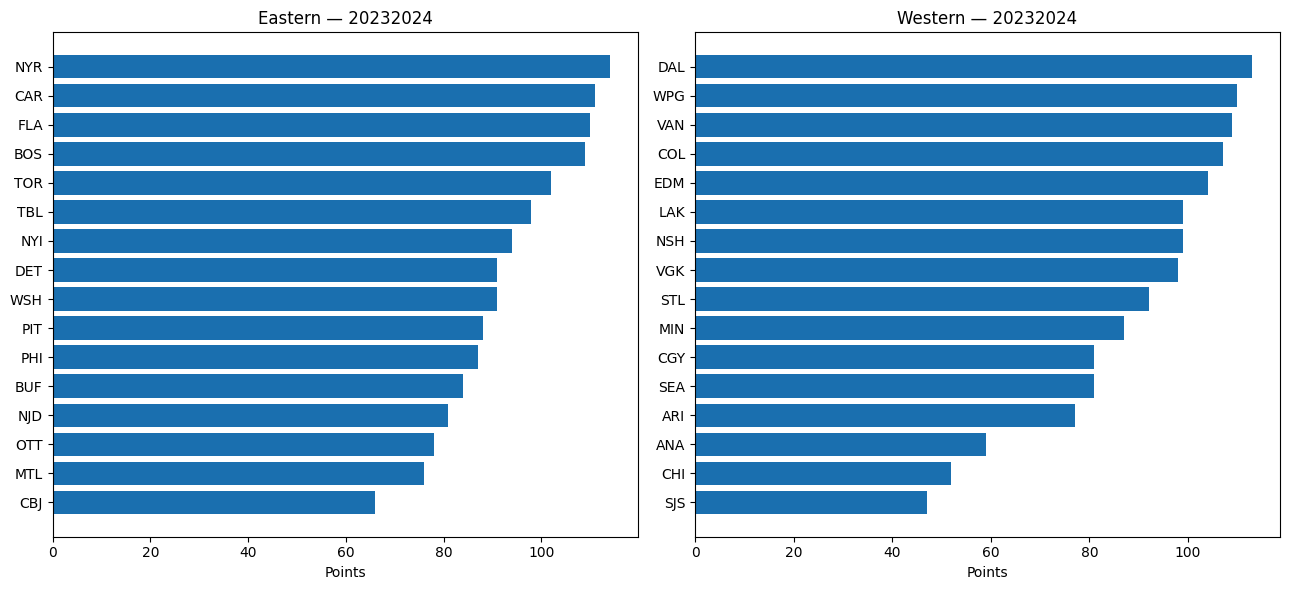

In [5]:
# Points distribution by conference for the most recent season
season = df['season'].max()
season_df = df[df['season'] == season].copy()

conferences = season_df['conference'].dropna().unique()
fig, axes = plt.subplots(1, len(conferences), figsize=(13, 6))
if len(conferences) == 1:
    axes = [axes]

for ax, conf in zip(axes, sorted(conferences)):
    subset = season_df[season_df['conference'] == conf].sort_values('points')
    ax.barh(subset['team'], subset['points'], color='#1a6faf')
    ax.set_title(f'{conf} — {season}')
    ax.set_xlabel('Points')

plt.tight_layout()
plt.show()

## Points by conference (most recent season)

A quick look at how points are distributed across teams in the most recent season. Each bar is one team — longer bars mean more points. The top 8 teams in each conference qualify for the playoffs, so the cutoff is roughly visible as the point where the bars start getting noticeably shorter.

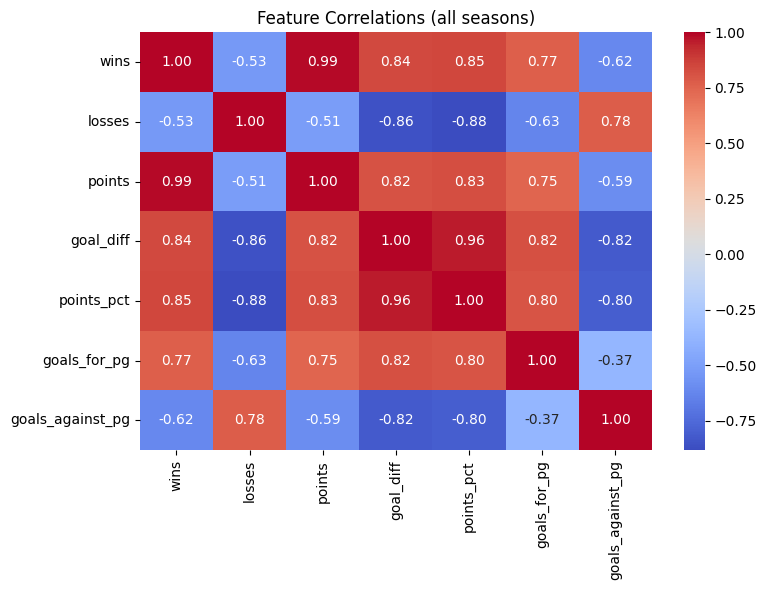

In [6]:
# Correlation heatmap across all seasons
numeric = df[['wins', 'losses', 'points', 'goal_diff', 'points_pct', 'goals_for_pg', 'goals_against_pg']]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlations (all seasons)')
plt.tight_layout()
plt.show()

## Feature correlation heatmap

Shows how strongly each pair of stats moves together across all team-seasons. Values close to **+1** mean the two stats rise and fall together; values close to **-1** mean they move in opposite directions.

A few things to look for:
- `points`, `wins`, and `win_pct` are highly correlated with each other — they're essentially measuring the same thing
- `goal_diff` correlates strongly with points, which makes sense: teams that outscore opponents win more games
- `goals_against_pg` has a negative correlation with points — giving up fewer goals per game is associated with a better record

C:\Users\style\AppData\Local\Temp\ipykernel_46356\2790758193.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_season, labels=seasons_sorted)


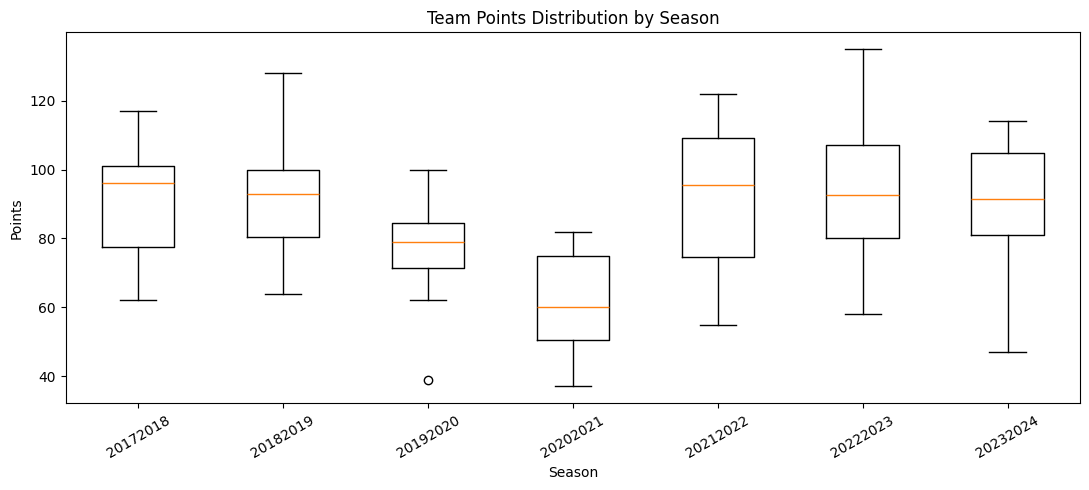

In [7]:
# Points distribution across all seasons (box plot per season)
fig, ax = plt.subplots(figsize=(11, 5))
seasons_sorted = sorted(df['season'].unique())
data_by_season = [df[df['season'] == s]['points'].values for s in seasons_sorted]
ax.boxplot(data_by_season, labels=seasons_sorted)
ax.set_xlabel('Season')
ax.set_ylabel('Points')
ax.set_title('Team Points Distribution by Season')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Points distribution by season

Box plots show the spread of team points for each season. The box covers the middle 50% of teams, the line inside is the median, and the whiskers extend to the full range.

Things to note:
- The 2019–20 season (COVID pause) and 2020–21 season (shortened 56-game schedule) show tighter distributions and slightly different point totals due to fewer games played
- Most seasons have a fairly consistent spread, suggesting the competitive balance of the league hasn't changed dramatically year to year